<center><h1>Blackburn_Brianna_HW2</h1></center>
<br>
<br>

Name: Brianna Blackburn

Github Username: BlackburnBC

USC ID: 9006039317

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [144]:
%pip install ucimlrepo
%pip install scikit-learn
%pip install seaborn
%pip install matplotlib.pyplot

import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: C:\Users\bb76060\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: C:\Users\bb76060\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: C:\Users\bb76060\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: C:\Users\bb76060\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Get the Cycle Power Plant Data Set

In [145]:
#read data from https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant
plant_columns = fetch_ucirepo(id=294) 
  
#create dataframe
X = plant_columns.data.features 
y = plant_columns.data.targets 

plant_df = pd.concat([X, y], axis=1)

### (b) Exploring the data

#### i. rows and columns

In [146]:
#number of rows and columns in plant_df dataset, top 5 rows preview and basic descriptive statistics
print(plant_df.shape)
print(plant_df.head())
print(plant_df.describe()) 


(9568, 5)
        AT        V         AP       RH        PE
0 14.96000 41.76000 1024.07000 73.17000 463.26000
1 25.18000 62.96000 1020.04000 59.08000 444.37000
2  5.11000 39.40000 1012.16000 92.14000 488.56000
3 20.86000 57.32000 1010.24000 76.64000 446.48000
4 10.82000 37.50000 1009.23000 96.62000 473.90000
              AT          V         AP         RH         PE
count 9568.00000 9568.00000 9568.00000 9568.00000 9568.00000
mean    19.65123   54.30580 1013.25908   73.30898  454.36501
std      7.45247   12.70789    5.93878   14.60027   17.06699
min      1.81000   25.36000  992.89000   25.56000  420.26000
25%     13.51000   41.74000 1009.10000   63.32750  439.75000
50%     20.34500   52.08000 1012.94000   74.97500  451.55000
75%     25.72000   66.54000 1017.26000   84.83000  468.43000
max     37.11000   81.56000 1033.30000  100.16000  495.76000


Answer: The columns represent four distinct features/variables (independent) measured through out the energy plant cycle and fifth variable being the target (dependent variable) which is the output of the energy cycle. Rows are observations, so each time the cycle was ran. Combined, that creates an instance.

#### ii. pairwise scatterplots of all the varianbles

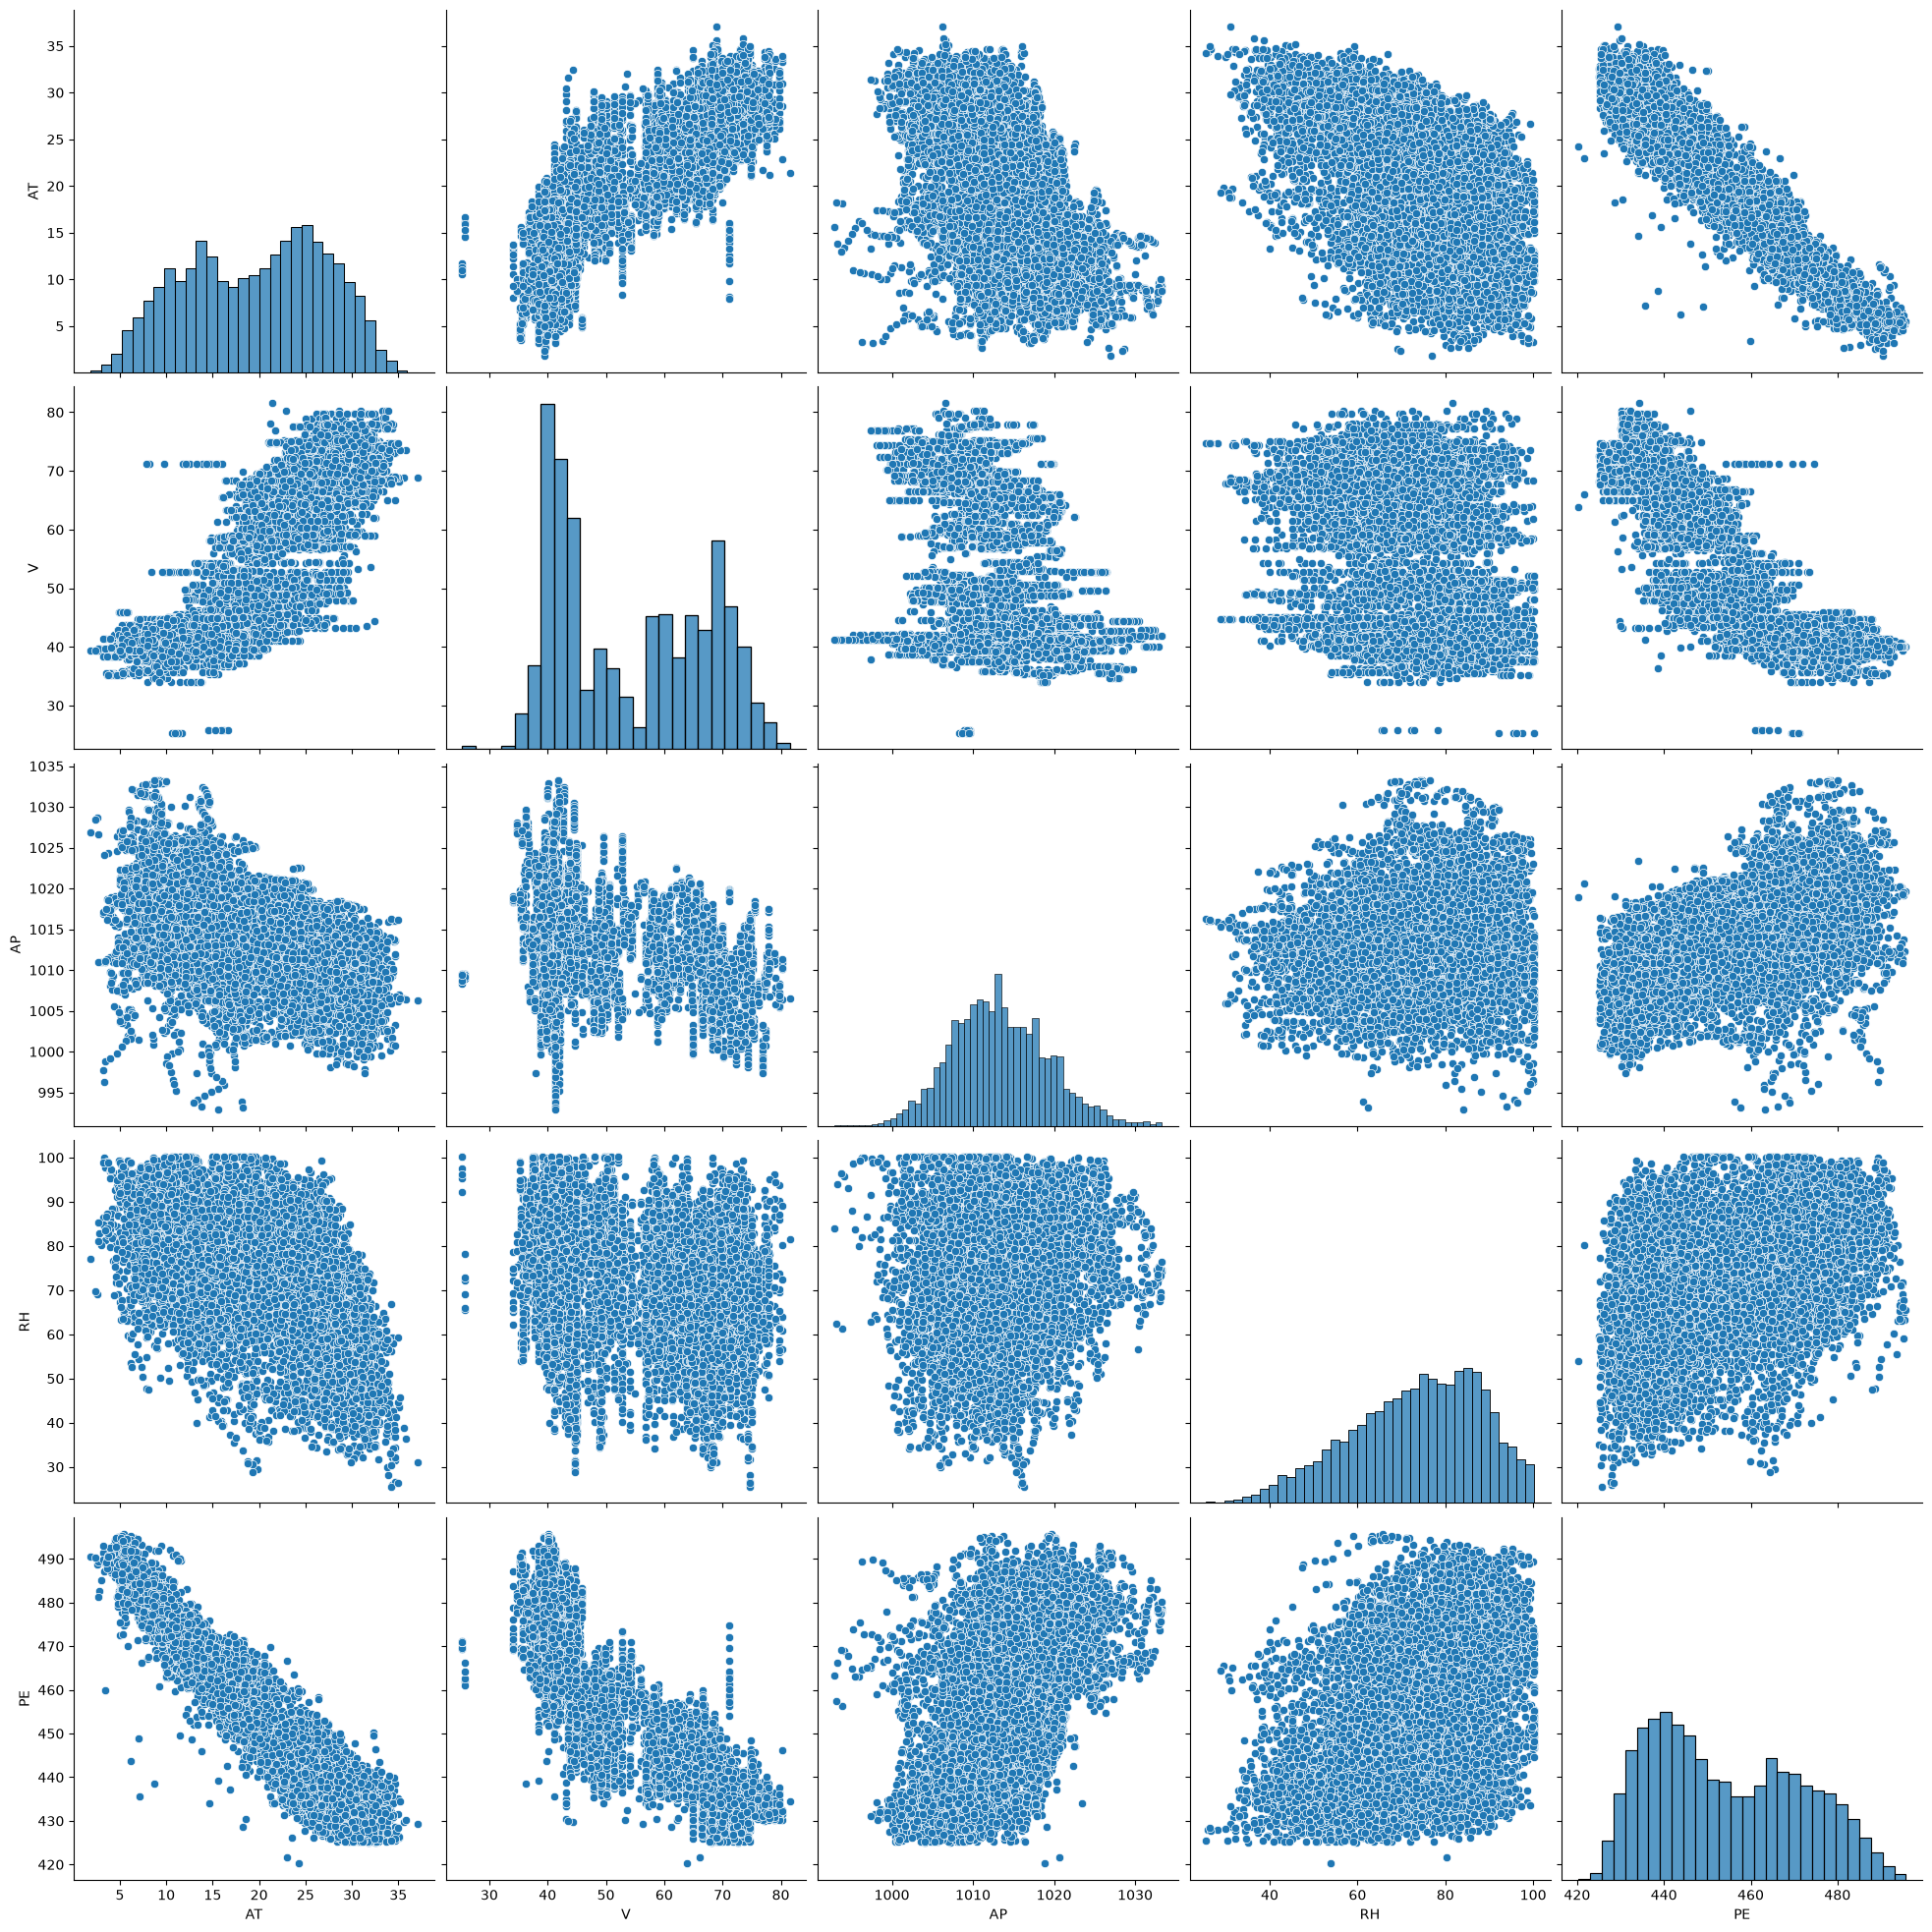

In [147]:
#pairplots of all variables against each other
sns.pairplot(plant_df,height=4,aspect=1,)
plt.show()


Answer: AT of all independent variables shows an approximately linear (though negative) relationship to the output dependent variable PE. Similarly, V has a rought negative linear relationship visually with PE. AT and V scatterplot linear negative lines could indicate a correlation that is worth exploring. On the contrary, the larger clusters (blob shaped) shows that some relationships between predictors and the target are not strictly linear. Visually, there are outliers within each variable and these plots show potential outer boundaries.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [148]:
#descriptive statistics of dataframe
#AI prompt: can I create a loop that runs specific descriptive statistics for each variable and have the...
#output automatically organized in a table?
#Note: I am working on understanding and getting a hang of loops....

plant_stats = []

for column in plant_df.columns:
    q1 = plant_df[column].quantile(0.25)
    q3 = plant_df[column].quantile(0.75)

    plant_stats.append({
        "Variable": column,
        "Mean": plant_df[column].mean(),
        "Median": plant_df[column].median(),
        "Range": plant_df[column].max() - plant_df[column].min(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1
    })

plant_stats_df = pd.DataFrame(plant_stats).round(2)

plant_stats_df

,Variable,Mean,Median,Range,Q1,Q3,IQR
0,AT,19.65000,20.34000,35.30000,13.51000,25.72000,12.21000
1,V,54.31000,52.08000,56.20000,41.74000,66.54000,24.80000
2,AP,1013.26000,1012.94000,40.41000,1009.10000,1017.26000,8.16000
3,RH,73.31000,74.97000,74.60000,63.33000,84.83000,21.50000
4,PE,454.37000,451.55000,75.50000,439.75000,468.43000,28.68000


### (c) Simple Linear Regression

AT Linear Regression Performance
1. Intercept -  [497.03411989]
2. Coefficient -  [-2.17131996]
3. Rsquared -  0.8989475964148236


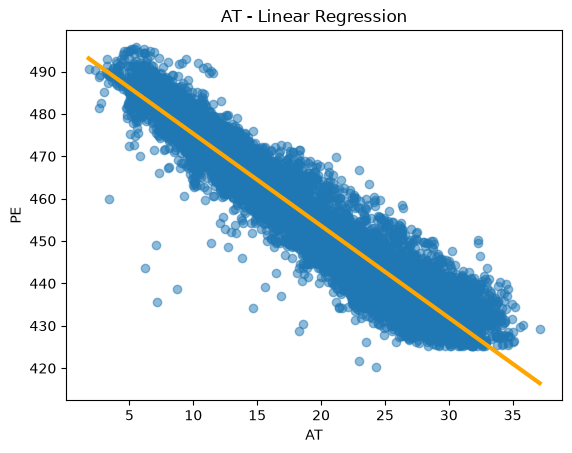

V Linear Regression Performance
1. Intercept -  [517.80152631]
2. Coefficient -  [-1.16813513]
3. Rsquared -  0.7565177870683979


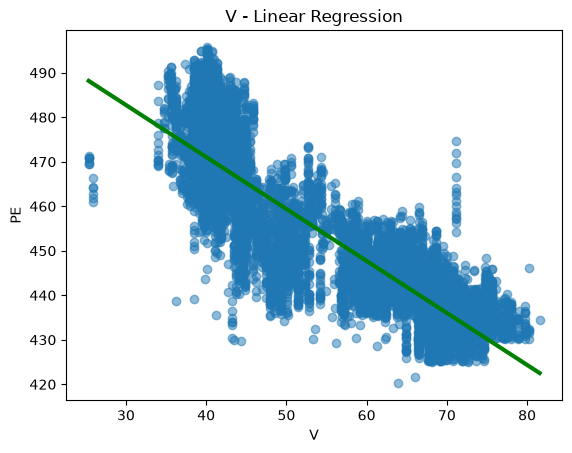

AP Linear Regression Performance
1. Intercept -  [-1055.26098898]
2. Coefficient -  [1.48987167]
3. Rsquared -  0.2687686564110673


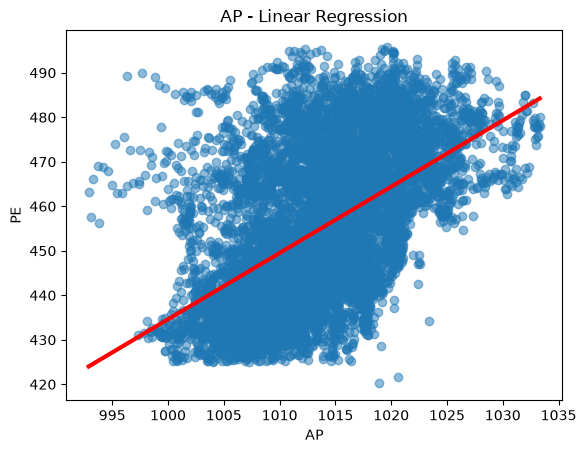

RH Linear Regression Performance
1. Intercept -  [420.96176616]
2. Coefficient -  [0.4556501]
3. Rsquared -  0.15193944023117578


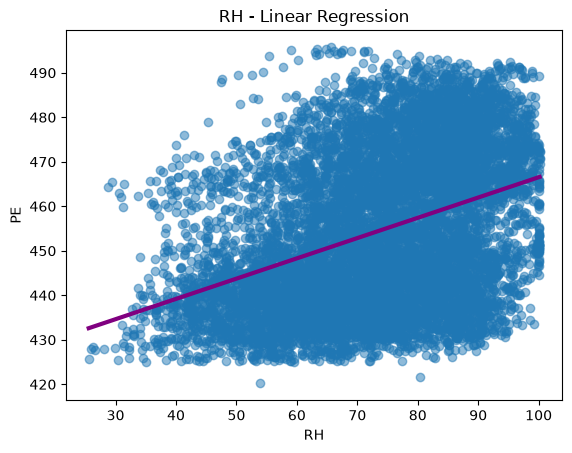

In [149]:
#Linear regression for predictor AT
X_AT = X[['AT']]

linear_model = LinearRegression()
linear_model.fit(X_AT, y)

print("AT Linear Regression Performance")
print("1. Intercept - ", linear_model.intercept_)
print("2. Coefficient - ", linear_model.coef_[0])
print("3. Rsquared - ", linear_model.score(X_AT ,y))

plant_df['Predicted AT'] = linear_model.predict(X_AT)

#Plot AT performance - predicted vs actual 
AT_values = X['AT'].sort_values().index

plt.scatter(X['AT'], y.iloc[:, 0], alpha= 0.5, label= 'Actual')
plt.plot(X.loc[AT_values, 'AT'], plant_df.loc[AT_values, 'Predicted AT'],
         color='orange', linewidth=3,label='Predicted')
plt.title('AT - Linear Regression')
plt.xlabel('AT')
plt.ylabel('PE')
plt.show()

#____________________________________________________
#Linear regression for predictor V
X_V = X[['V']]

linear_model = LinearRegression()
linear_model.fit(X_V, y)

print("V Linear Regression Performance")
print("1. Intercept - ", linear_model.intercept_)
print("2. Coefficient - ", linear_model.coef_[0])
print("3. Rsquared - ", linear_model.score(X_V ,y))

plant_df['Predicted V'] = linear_model.predict(X_V)

#Plot V performance - predicted vs actual 
V_values = X['V'].sort_values().index

plt.scatter(X['V'], y.iloc[:, 0], alpha= 0.5, label= 'Actual')
plt.plot(X.loc[V_values, 'V'], plant_df.loc[V_values, 'Predicted V'],
         color='green', linewidth=3,label='Predicted')
plt.title('V - Linear Regression')
plt.xlabel('V')
plt.ylabel('PE')
plt.show()

#_______________________________________________________
#Linear regression for predictor AP
X_AP = X[['AP']]

linear_model = LinearRegression()
linear_model.fit(X_AP, y)

print("AP Linear Regression Performance")
print("1. Intercept - ", linear_model.intercept_)
print("2. Coefficient - ", linear_model.coef_[0])
print("3. Rsquared - ", linear_model.score(X_AP ,y))

plant_df['Predicted AP'] = linear_model.predict(X_AP)

#Plot AP linear performance - predicted vs actual 
AP_values = X['AP'].sort_values().index

plt.scatter(X['AP'], y.iloc[:, 0], alpha= 0.5, label= 'Actual')
plt.plot(X.loc[AP_values, 'AP'], plant_df.loc[AP_values, 'Predicted AP'],
         color='red', linewidth=3,label='Predicted')
plt.title('AP - Linear Regression')
plt.xlabel('AP')
plt.ylabel('PE')
plt.show()

#_______________________________________________________
#Linear regression for predictor RH
X_RH = X[['RH']]

linear_model = LinearRegression()
linear_model.fit(X_RH, y)

print("RH Linear Regression Performance")
print("1. Intercept - ", linear_model.intercept_)
print("2. Coefficient - ", linear_model.coef_[0])
print("3. Rsquared - ", linear_model.score(X_RH ,y))

plant_df['Predicted RH'] = linear_model.predict(X_RH)

#Plot RH linear performance - predicted vs actual 
RH_values = X['RH'].sort_values().index

plt.scatter(X['RH'], y.iloc[:, 0], alpha= 0.5, label= 'Actual')
plt.plot(X.loc[RH_values, 'RH'], plant_df.loc[RH_values, 'Predicted RH'],
         color='purple', linewidth=3,label='Predicted')
plt.title('RH - Linear Regression')
plt.xlabel('RH')
plt.ylabel('PE')
plt.show()


Answer: Based on the R-squared stats which shows the linear strength between predictor and target variable AT (0.8) is closest to 1 meaning a stronger fit linear relationship between AT and PE than other predictor variables which measure further from 1 and closer to 0. The negative coefficient indicates a negative relationship so as AT (temperature) increases, PE (energy) value decreases. The same goes for interpretting the coefficients of other variables (postive value means positive direction or increase and vice versa), but the value itself does not indicate strength in model, just the unit on average that the predictor changes PE prediction. 
According to the plots, these observations on AT which shows a tighter packed cluster along the linear plane is backs up my claims.
As for outliers, it depends. There are evident outliers in the AT model but because of linear strength I am a little more confident that they don't impact model performance. It these outliers are errors and can be identified as so, then yes, but they could be true observations in machine outputs and inputs. For the other predictor variables, because of the shape of the distribution being less defined, it could be more difficult to interpret outliers. My decision is more based on visual interpretation and intuition but using a threshold to determine what outliers to exclude can be used and then models rerun to test change in results.

### (d) Multiple Regression

In [150]:
#Multiple linear regression of predictor variables
multi_model = LinearRegression()
multi_model.fit(X, y)

plant_df['Predicted Multiple'] = multi_model.predict(X).ravel()

print("Multiple Linear Regression Performance")
print("1. Intercept - ", multi_model.intercept_)
print("2. Rsquared - ", multi_model.score(X ,y))

coef_results = pd.DataFrame({'Variable': X.columns, 'Coefficient': multi_model.coef_[0]})
print(coef_results)

#Use statsmodel to add p-value stat for hypothesis testing 
#(messed up and built using sklearn intially but keeping both in)
X_constant = sm.add_constant(X)

stats_model = sm.OLS(y.iloc[:, 0], X_constant).fit()

print(stats_model.summary())
print(stats_model.pvalues)

p_value = pd.DataFrame({
    'p-value': stats_model.pvalues
})

pd.options.display.float_format = '{:.10f}'.format
print(p_value)

Multiple Linear Regression Performance
1. Intercept -  [454.60927432]
2. Rsquared -  0.9286960898122537
  Variable  Coefficient
0       AT     -1.97751
1        V     -0.23392
2       AP      0.06208
3       RH     -0.15805
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:43:58   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                            

Answer: Just going off of pvalue results, We reject the null hypothesis if we use the usual pvalue of 0.05. All predictor variables are significantly below that threshold showing that on its own as a predictor it is strongly statistically significant. This is interesting and raises some question about the strength of pvalue in this instance to make this inference especially with what we know about the shape of the data to the linear fit.

### (e) 1c Compare to 1d

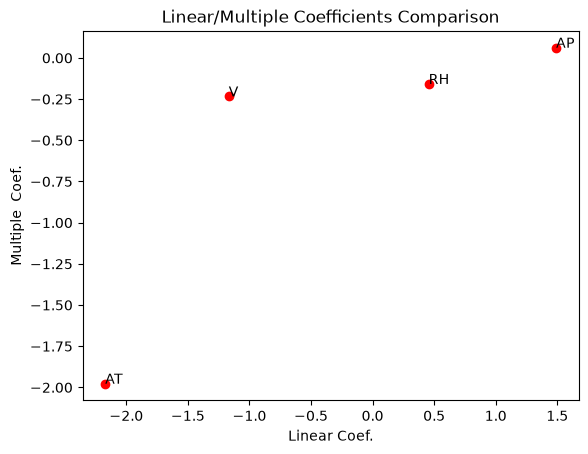

  Predictors        Linear      Multiple
0         AT -2.1713199585 -1.9775131066
1          V -1.1681351266 -0.2339164226
2         AP  1.4898716734  0.0620829438
3         RH  0.4556501023 -0.1580541029


In [151]:

#collect all linear coefficients for all predictor variables into one object
linear_coef = []

for predictor in X.columns:
    linear_model = LinearRegression()
    linear_model.fit(X[[predictor]], y)

    linear_coef.append(linear_model.coef_[0][0])

#Store multiple regression coefficients into a single object
multi_coef = multi_model.coef_[0]

#Create dataframe of linear and multiple coefficients for all predictors
coef_comparison = pd.DataFrame({'Predictors': X.columns,'Linear': linear_coef,'Multiple': multi_coef})

#Plot coefficient comparisons
plt.scatter(coef_comparison['Linear'],coef_comparison['Multiple'], color='red')

for i, predictor in enumerate(coef_comparison['Predictors']):
    plt.text(coef_comparison['Linear'][i],coef_comparison['Multiple'][i],predictor)

plt.xlabel('Linear Coef.')
plt.ylabel('Multiple  Coef.')
plt.title('Linear/Multiple Coefficients Comparison')

plt.show()
print(coef_comparison)

Answer: Comparing each predictor variables coefficients between the linear and multiple regressions models, all variables but AT show a big difference in coffecient value range. AT coefficient is ever so slightly different between regression models. Looking at the dataframe I find it easier to see that the linear regression coefficients for V, AP, and RH are larger than their multiple regression coefficient counterpart, and for RH specifically there was a change in its negative direction in relation to EP. The difference we see when all predictors relationships to PE are assessed with each other in the multiple regression model uncovers possible correlation between predictors.  

### (f) Nonlinear Association

In [152]:
#Nonlinear formula testing squared and cubed association to target PE
AT_nonlinear = smf.ols(formula='PE ~ AT + I(AT**2) + I(AT**3)',data=plant_df).fit()
V_nonlinear = smf.ols(formula='PE ~ V + I(V**2) + I(V**3)',data=plant_df).fit()
AP_nonlinear = smf.ols(formula='PE ~ AP + I(AP**2) + I(AP**3)',data=plant_df).fit()
RH_nonlinear = smf.ols(formula='PE ~ RH + I(RH**2) + I(RH**3)',data=plant_df).fit()

#Combine squared, cubed, and linear pvalues into dataframe
pvalue_nonlinear = pd.DataFrame(
    {'AT': AT_nonlinear.pvalues.values,'V': V_nonlinear.pvalues.values,'AP': AP_nonlinear.pvalues.values,'RH': RH_nonlinear.pvalues.values},
    index=['Intercept', 'Linear', 'Squared', 'Cubed']).T

pd.options.display.float_format = '{:.10f}'.format
print(pvalue_nonlinear)

      Intercept       Linear      Squared        Cubed
AT 0.0000000000 0.0000007898 0.0000000000 0.0000000000
V  0.0000000000 0.0000252659 0.7684969444 0.0137348859
AP 0.0000000000 0.0000000000 0.0000000000 0.0000000000
RH 0.0000000000 0.0003772510 0.0000093954 0.0000144028


C:\Users\bb76060\AppData\Local\Temp\ipykernel_26876\3899911312.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  AP_nonlinear = smf.ols(formula='PE ~ AP + I(AP**2) + I(AP**3)',data=plant_df).fit()


Answer: There is general pvalue evidence (<0.05) of non-linear association (both squared and cubed) between each variable and PE, except for V which only shows statistically significant evidence for cubed nonlinear. So although AT has a stronger linear tendency between it and PE as the unit decreases, the evidence of squared and cubed nonlinear means the rate that units decrease/increase is not constant across all values in AT. Thats what it shows strongly for the other variables nonlinearly more so than a linear association.

### (g) Interactions of Predictors

In [153]:
#Linear regression with pairwise interaction terms
pairwise_model = smf.ols(formula='PE ~ (AT + V + AP + RH)**2', data=plant_df).fit()

print(pairwise_model.summary())

pairwise_results = pd.DataFrame({'Coef': pairwise_model.params,'Pvalue': pairwise_model.pvalues})
pairwise_results.style.format({'Coef': '{:.6f}','Pvalue': '{:.10f}'})

pairwise_results

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:43:58   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

,Coef,Pvalue
Intercept,685.7824681462,0.0000000000
AT,-4.3470141201,0.0670187269
V,-7.6748576340,0.0000000137
AP,-0.1523546417,0.0473573175
RH,1.5709070481,0.0422521333
AT:V,0.0209709231,0.0000000000
AT:AP,0.0017590452,0.4520508834
AT:RH,-0.0052303536,0.0000000001
V:AP,0.0068123543,0.0000002877
V:RH,0.0008386332,0.0861936598


Answer: Yes, by testing pairwise interaction terms between all predictors we can see from pvalue statistical significance that some variables have interactions between each other when all else is constant: AT:V, AT:RH, V:AP, and AP:RH. Throwing in coefficient, we can see the direction of the interaction/association. For example, AT:V coefficient shows that a positive effect occurs, meaning ATs association on PE moves positive/increases as V also increases. The pvalue for AT:V essentially means that there is statistically significant evidence that AT's impact on PE may depend on V variable.

### (h) Improvement

In [154]:
#Split data into 70% train and and 30% test using random holdout method
train_df, test_df = train_test_split(plant_df, train_size=0.70, random_state=42)

#Regression model all variables 
regression_model = smf.ols(formula='PE ~ AT + V + AP + RH', data=train_df).fit()

regression_train_pred = regression_model.predict(train_df)
regression_test_pred = regression_model.predict(test_df)

regression_MSE_train = mean_squared_error(train_df['PE'], regression_train_pred)
regression_MSE_test = mean_squared_error(test_df['PE'], regression_test_pred)

#Quadratic nonlinear regression with interaction terms
quad_formula = """PE ~ (AT + V + AP + RH)**2 + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)"""

quad_regression_model = smf.ols(formula=quad_formula, data=train_df).fit()

print(quad_regression_model.summary())

quad_pvalues = quad_regression_model.pvalues.drop(['Intercept', 'AT', 'V', 'AP', 'RH']
).sort_values(ascending=False)

print(quad_pvalues)

#V:RH term has highest pvalue (0.8) - remove from formula
formula_1 = """PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + AP:RH + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)"""

regression_model_1 = smf.ols(formula=formula_1, data=train_df).fit()
regression_model1_pvalues = regression_model_1.pvalues.drop(['Intercept', 'AT', 'V', 'AP', 'RH']
).sort_values(ascending=False)

print("\n Removed V:RH")
print(regression_model1_pvalues)

#V quadratic term has highest pvalue now (0.6) - remove from formula
formula_2 = """PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + AP:RH + I(AT**2) + I(AP**2) + I(RH**2)"""

regression_model_2 = smf.ols(formula=formula_2, data=train_df).fit()
regression_model_2_pvalues = regression_model_2.pvalues.drop(['Intercept', 'AT', 'V', 'AP', 'RH']
).sort_values(ascending=False)

print("\n Removed V**2")
print(regression_model_2_pvalues)

#Remove V:AP interaction term has highest pvalue (0.3)
formula_3 = """PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + AP:RH + I(AT**2) + I(AP**2) + I(RH**2)"""

regression_model_3 = smf.ols(formula=formula_3, data=train_df).fit()
regression_model3_pvalues = regression_model_3.pvalues.drop(['Intercept', 'AT', 'V', 'AP', 'RH']
).sort_values(ascending=False)

print("\n Removed V:AP")
print(regression_model3_pvalues)

#Final regression model with reduced terms (removed V:RH, V quadratic, and V:AP)
final_regression_model = regression_model_3

print("\n", final_regression_model.model.formula)
print(final_regression_model.pvalues)

final_train_pred = final_regression_model.predict(train_df)
final_test_pred = final_regression_model.predict(test_df)

#Train and test final regression model mean squared error
MSE_train = mean_squared_error(train_df['PE'], final_train_pred)
MSE_test = mean_squared_error(test_df['PE'], final_test_pred)

#Test compare initial linear regression model and the reduced quadratic nonlinear regression model
MSE_results_final = pd.DataFrame({'Model': ['Linear Regression','Final Quadratic/Interaction Regression'],
    'Train MSE': [regression_MSE_train, MSE_train],
    'Test MSE': [regression_MSE_test, MSE_test]})

print(MSE_results_final)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:43:58   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7664.9809   1429.568     -5.362      0.0

Answer: Yes, comparing mean squared error (avg difference between the targets actual and predicted values squared) the quadratic interaction regression has a lower MSE compared to the initial linear regression which contained all variables. By iterating through weak predictor pvalues and eliminating them, we were able to strengthen models prediction performance. Additionally, for both models, the MSE between training and testing datasets remained close in measure we can also assure that there is no overt overfitting that occurred.

### (i) KNN

   k          1/k  ...  Normalized Train MSE  Normalized Test MSE
0  1 1.0000000000  ...          0.0000000000        18.6248883316
1  2 0.5000000000  ...          5.2763326042        15.4959968304
2  3 0.3333333333  ...          7.3006693777        14.6331814660
3  4 0.2500000000  ...          8.5914328393        14.3056694227
4  5 0.2000000000  ...          9.7172950623        14.6598723985

[5 rows x 6 columns]
 
Best Raw K -  5
Best Raw Test MSE: -  15.726819842563568
 
Best Normalized K: -  4
Best Normalized Test MSE: -  14.305669422675024


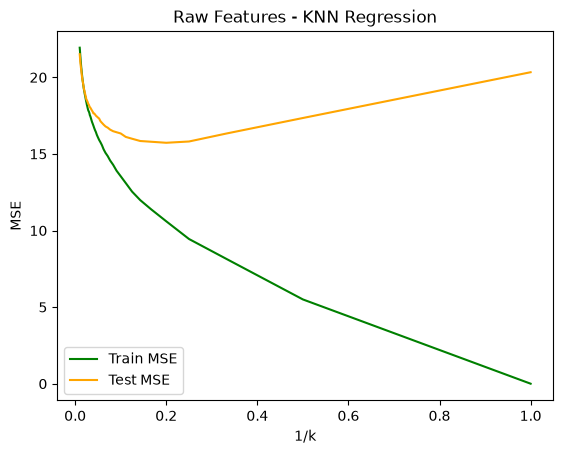

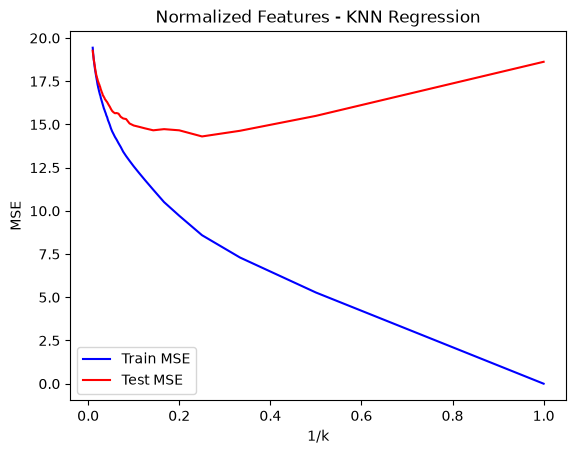

In [155]:
#K Nearest Neighbors - separate predictors btw train and test
predict_variables = ['AT', 'V', 'AP', 'RH']

X_train = train_df[predict_variables]
X_test = test_df[predict_variables]
y_train = train_df['PE']
y_test = test_df['PE']

#Standardize (normalize) predictor features bc of varying scales of measurement
normalize = StandardScaler()

scaled_X_train = normalize.fit_transform(X_train)
scaled_X_test = normalize.transform(X_test)

#KNN model loop for range of values
results = []

for k in range(1, 101):
    Raw_model = KNeighborsRegressor(n_neighbors=k)
    Raw_model.fit(X_train, y_train)
    Raw_train_pred = Raw_model.predict(X_train)
    Raw_test_pred = Raw_model.predict(X_test)

    Normalize_model = KNeighborsRegressor(n_neighbors=k)
    Normalize_model.fit(scaled_X_train, y_train)
    Normalize_train_pred = Normalize_model.predict(scaled_X_train)
    Normalize_test_pred = Normalize_model.predict(scaled_X_test)

    results.append({'k': k, '1/k': 1 / k, 'Raw Train MSE': mean_squared_error(y_train, Raw_train_pred),
        'Raw Test MSE': mean_squared_error(y_test, Raw_test_pred),
        'Normalized Train MSE': mean_squared_error(y_train, Normalize_train_pred),
        'Normalized Test MSE': mean_squared_error(y_test, Normalize_test_pred)})

KNN_results = pd.DataFrame(results)
print(KNN_results.head())

#Identify lowest MSE for best performance
best_raw_MSE = KNN_results.loc[KNN_results['Raw Test MSE'].idxmin()]
best_normal_MSE = KNN_results.loc[KNN_results['Normalized Test MSE'].idxmin()]

print(" ")
print("Best Raw K - ", int(best_raw_MSE['k']))
print("Best Raw Test MSE: - ", best_raw_MSE['Raw Test MSE'])
print(" ")
print("Best Normalized K: - ", int(best_normal_MSE['k']))
print("Best Normalized Test MSE: - ", best_normal_MSE['Normalized Test MSE'])

#Plot raw then normalized feature errors for KNN regression model 
#______________Raw
plot_KNN_results = KNN_results.sort_values('1/k')

plt.plot(plot_KNN_results['1/k'], plot_KNN_results['Raw Train MSE'], color="green", label='Train MSE')
plt.plot(plot_KNN_results['1/k'], plot_KNN_results['Raw Test MSE'], color="orange", label='Test MSE')

plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('Raw Features - KNN Regression')
plt.legend()
plt.show()

#_____________Normalized
plt.plot(plot_KNN_results['1/k'], plot_KNN_results['Normalized Train MSE'], color="blue", label='Train MSE')

plt.plot(plot_KNN_results['1/k'], plot_KNN_results['Normalized Test MSE'], color="red", label='Test MSE')

plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('Normalized Features - KNN Regression')
plt.legend()
plt.show()

### (j ) Compare KNN and Linear

In [156]:
#Linear and KNN model comparison table
model_performance = pd.DataFrame({'Model':['Final Quadratic/Interaction Regression','KNN Raw Features','KNN Normalized Features'], 
    'Best k': [None, int(best_raw_MSE['k']), int(best_normal_MSE['k'])],
    'Train MSE': [MSE_train, best_raw_MSE['Raw Train MSE'], best_normal_MSE['Normalized Train MSE']],
    'Test MSE': [MSE_test, best_raw_MSE['Raw Test MSE'], best_normal_MSE['Normalized Test MSE']]})

model_performance
model_performance.sort_values(by='Test MSE').reset_index(drop=True)

,Model,Best k,Train MSE,Test MSE
0,KNN Normalized Features,4.0000000000,8.5914328393,14.3056694227
1,KNN Raw Features,5.0000000000,10.6007688876,15.7268198426
2,Final Quadratic/Interaction Regression,NaN,17.8908427732,18.6600404951


Answer: Analyzing the model performance comparisons table, the normalization of features improved model performance showing smaller MSE compared to the raw features (as is). The models between themselves provided different K values to note. What we also should note is that both KNN models have a gap in MSE between their training model and test model performance (look out for potential overfitting). Comparing that aspect, the quadratic interaction regression model produces a smaller gap in MSE between training and testing model performance. Of all three models and both train and test runs, the normaled feature KNN model out performance the other. Since KNN out performed linear regression, we can also make the assumption that relationships between the predictor variables to PE can be non-linear in characteristics.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

Answer: In this case, because we have a more rhobust observation dataset size, a more complex flexible model would be feasible and theoretically perform well. 

### (b) The number of predictors p is extremely large, and the number of observations n is small.

Answer: For the opposite, a flexible model would perform worse by overfitting due to too few observations to train on and an inflexible model is perferred. 

### (c) The relationship between the predictors and response is highly non-linear.

Answer: As learned from our prior exercises when testing the linearity of the electricity model, a highly nonlinear relationship would perform well with a flexible model because it better captures the complex shape of the data whereas a linear one would more likely miss.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

Answer: For this, a flexible model would be worse for a dataset that contains high amount of noise. The noise would influence the fit of the flexible model and identify unmeaningful data as meaningful to its training pattern.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [159]:
#Create dataframe and determine euclidian distancefrom test point (0,0,0)
df = pd.DataFrame({
    'Obs': [1, 2, 3, 4, 5, 6],
    'X1': [0, 2, 0, 0, -1, 1],
    'X2': [3, 0, 1, 1, 0, 1],
    'X3': [0, 0, 3, 2, 1, 1],
    'Y': ['Red', 'Red', 'Red', 'Green', 'Green', 'Red']})

test_point = np.array([0, 0, 0])

df['e Distance'] = np.linalg.norm(df[['X1', 'X2', 'X3']].to_numpy() - test_point, axis=1)
print(df)

   Obs  X1  X2  X3      Y   e Distance
0    1   0   3   0    Red 3.0000000000
1    2   2   0   0    Red 2.0000000000
2    3   0   1   3    Red 3.1622776602
3    4   0   1   2  Green 2.2360679775
4    5  -1   0   1  Green 1.4142135624
5    6   1   1   1    Red 1.7320508076


### (b) What is our prediction with K = 1? Why?

In [160]:
df.sort_values('e Distance')

,Obs,X1,X2,X3,Y,e Distance
4,5,-1,0,1,Green,1.4142135624
5,6,1,1,1,Red,1.7320508076
1,2,2,0,0,Red,2.0000000000
3,4,0,1,2,Green,2.2360679775
0,1,0,3,0,Red,3.0000000000
2,3,0,1,3,Red,3.1622776602


Answer: When K = 1 (-1, 0, 1)our prediction would be green given the closest euclidian distance to the test point is observation 5 with the target value green.

### (c) What is our prediction with K = 3? Why?

In [161]:
df.sort_values('e Distance').head(3)

,Obs,X1,X2,X3,Y,e Distance
4,5,-1,0,1,Green,1.4142135624
5,6,1,1,1,Red,1.7320508076
1,2,2,0,0,Red,2.0000000000


Answer: Given K = 3, the first three observations closest to the test point are 5, 6, 2. Since there are two classification labels in the mix (green and red), majority vote would classify the instance as red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

Answer: For highly non-linear decision boundary, small K value would be the best because it provides more flexibility in determining the decision boundary. The higher value of K produces a closer to linear decision boundary which would have a higher error rate for model performance.